<a href="https://colab.research.google.com/github/siga-epitech/T-WORK-IA/blob/dev/img-predict-learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow.keras.preprocessing import image

# Charger les données MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normaliser les images
x_train, x_test = x_train / 255.0, x_test / 255.0


In [10]:
# Créer le modèle
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),  # Aplatir l'image 28x28 en un vecteur
  tf.keras.layers.Dense(128, activation='relu'),  # Couche dense avec 128 neurones
  tf.keras.layers.Dropout(0.2),                   # Dropout pour éviter l'overfitting
  tf.keras.layers.Dense(10)                       # 10 sorties, une par chiffre
])

predictions = model(x_train[:1]).numpy()
predictions
tf.nn.softmax(predictions).numpy()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
loss_fn(y_train[:1], predictions).numpy()
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])


In [18]:
# Entraîner le modèle
model.fit(x_train, y_train, epochs=20)  # Augmenter le nombre d'époques

# Évaluer le modèle
model.evaluate(x_test, y_test, verbose=2)

probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])
probability_model(x_test[:5])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9910 - loss: 0.0278
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9904 - loss: 0.0277
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9907 - loss: 0.0277
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9914 - loss: 0.0246
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9921 - loss: 0.0242
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9910 - loss: 0.0260
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9922 - loss: 0.0218
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9914 - loss: 0.0236
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9928 - loss: 0.0226
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9928 - loss: 0.0207
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9926 - loss: 0.0203
Epoch 12/20
1875/1875 ━━━━━━━

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[1.78313480e-15, 1.59727310e-19, 4.36322818e-17, 1.18627037e-08,
        1.42940194e-26, 3.57763217e-13, 2.54415211e-27, 1.00000000e+00,
        2.97894969e-17, 6.58624336e-11],
       [7.88270257e-22, 2.50443031e-13, 1.00000000e+00, 4.10288860e-12,
        5.06445727e-35, 9.99617578e-18, 5.71301131e-19, 1.67154098e-27,
        2.13418885e-16, 2.07647221e-31],
       [8.01954118e-17, 9.99999762e-01, 3.69040243e-09, 1.01351854e-14,
        9.37890832e-09, 5.61917337e-15, 1.35639122e-09, 7.55931406e-09,
        2.87618093e-07, 3.70096477e-15],
       [1.00000000e+00, 5.19106430e-29, 1.20123485e-14, 2.06676103e-15,
        3.80801204e-25, 1.37895359e-12, 7.46939996e-15, 4.19123422e-14,
        1.26104429e-17, 1.00897894e-13],
       [7.28941185e-10, 1.30829731e-16, 9.65516122e-12, 4.67456996e-16,
        9.99394298e-01, 1.32181362e-13, 3.17480903e-11, 2.95204615e-07,
        7.63525770e-11, 6.05441630e-04]], dtype=float32)>

Saving chiffre-1-.jpg to chiffre-1- (5).jpg


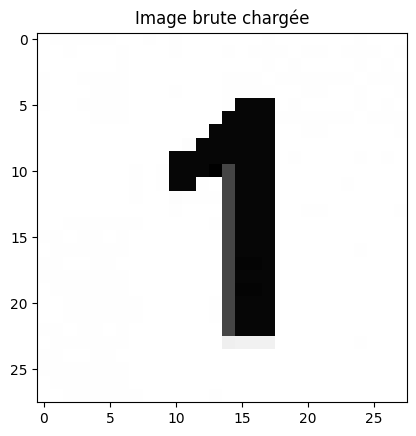

Forme de l'image brute : (28, 28)
Inversion des couleurs appliquée.


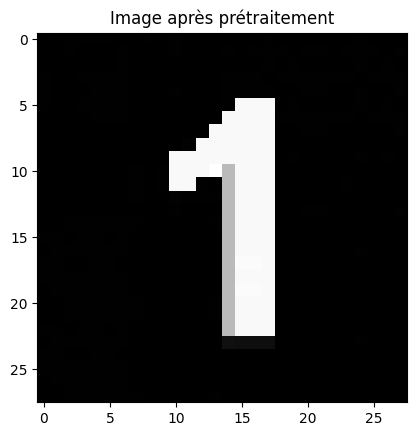

Forme de l'entrée après prétraitement : (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Probabilités pour chaque chiffre :
Chiffre 0: 0.00%
Chiffre 1: 19.28%
Chiffre 2: 0.00%
Chiffre 3: 8.83%
Chiffre 4: 0.00%
Chiffre 5: 0.00%
Chiffre 6: 0.00%
Chiffre 7: 67.54%
Chiffre 8: 0.00%
Chiffre 9: 4.34%
Prédiction finale : 7


In [27]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Télécharger un fichier depuis ton ordinateur
uploaded = files.upload()

# Nom du fichier téléchargé
img_path = list(uploaded.keys())[0]

# Charger l'image et la redimensionner à 28x28 en niveaux de gris
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

# Convertir l'image en tableau numpy
img_array = np.array(img)

# Afficher l'image brute pour voir si elle est bien chargée
plt.imshow(img_array, cmap='gray')
plt.title("Image brute chargée")
plt.show()

# Vérifier les dimensions de l'image brute
print(f"Forme de l'image brute : {img_array.shape}")

# Inverser les couleurs si nécessaire (MNIST a un fond noir et des chiffres blancs)
if img_array.mean() > 127:  # Si le fond semble blanc (moyenne des pixels élevée)
    img_array = 255 - img_array
    print("Inversion des couleurs appliquée.")

# Ajouter une dimension pour simuler un batch (1 image dans un batch)
img_array = img_array.reshape(1, 28, 28, 1)

# Normaliser l'image (comme fait avec MNIST)
img_array = img_array / 255.0

# Vérifier l'image prétraitée
plt.imshow(img_array[0, :, :, 0], cmap='gray')
plt.title("Image après prétraitement")
plt.show()

# Vérifier la forme de l'entrée
print(f"Forme de l'entrée après prétraitement : {img_array.shape}")

# Faire la prédiction avec le modèle
prediction = model.predict(img_array)

# Appliquer softmax pour obtenir des probabilités
prediction_probabilities = tf.nn.softmax(prediction).numpy()

# Afficher les probabilités pour chaque chiffre
print("Probabilités pour chaque chiffre :")
for i, prob in enumerate(prediction_probabilities[0]):
    print(f"Chiffre {i}: {prob * 100:.2f}%")

# Trouver la classe prédite (celle avec la probabilité la plus élevée)
predicted_label = prediction_probabilities.argmax()
print(f"Prédiction finale : {predicted_label}")


Clasification d'images simple :

In [1]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.17.1


In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

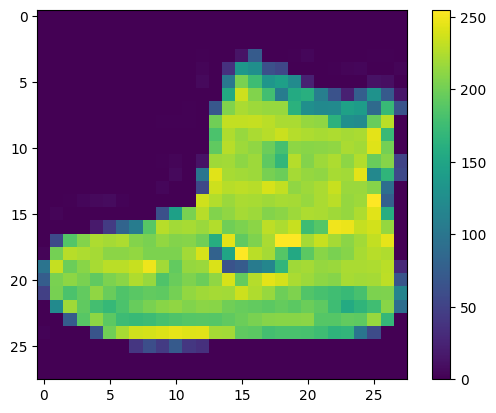

In [10]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [11]:
train_images = train_images / 255.0

test_images = test_images / 255.0

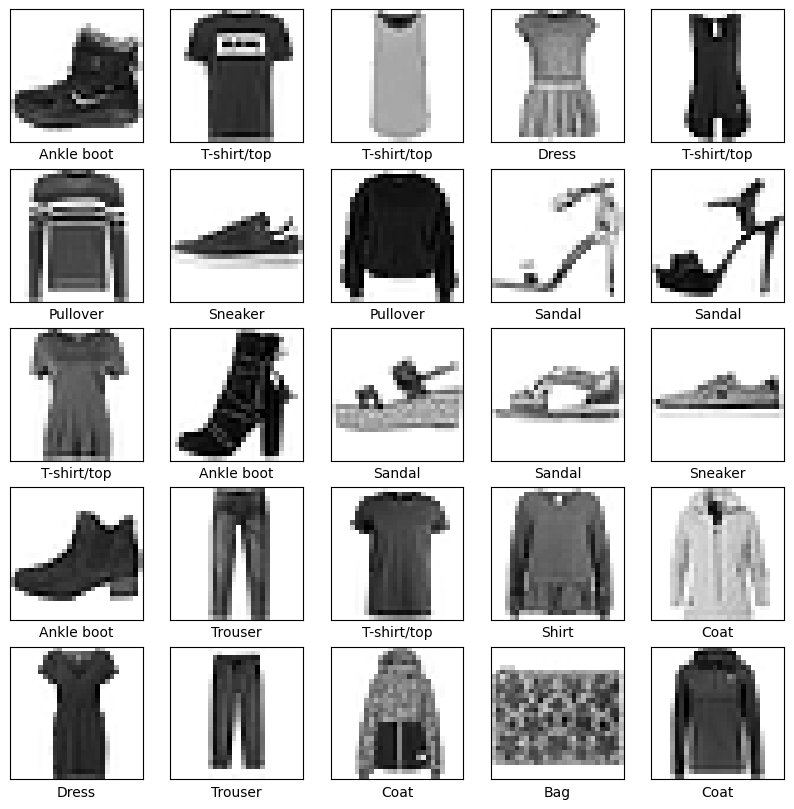

In [12]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [15]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7785 - loss: 0.6349
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8621 - loss: 0.3853
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8760 - loss: 0.3454
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8853 - loss: 0.3121
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8927 - loss: 0.2903
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8952 - loss: 0.2799
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9019 - loss: 0.2641
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9027 - loss: 0.2576
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9074 - loss: 0.2473
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9126 - loss: 0.2345


In [16]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8844 - loss: 0.3257

Test accuracy: 0.8844000101089478


In [20]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)
predictions[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.84406258e-06, 1.25220154e-10, 1.92061922e-09, 1.18776615e-08,
       7.60875665e-08, 2.42350550e-04, 1.10274947e-07, 1.39631992e-02,
       4.48162503e-08, 9.85792339e-01], dtype=float32)

In [21]:
np.argmax(predictions[0])

9

In [22]:
test_labels[0]

9

In [23]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

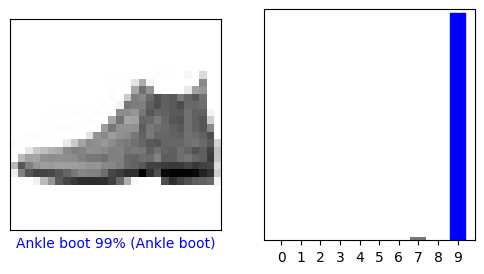

In [24]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

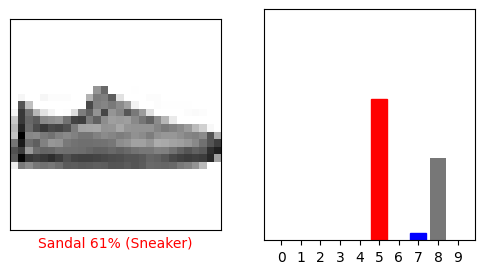

In [25]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

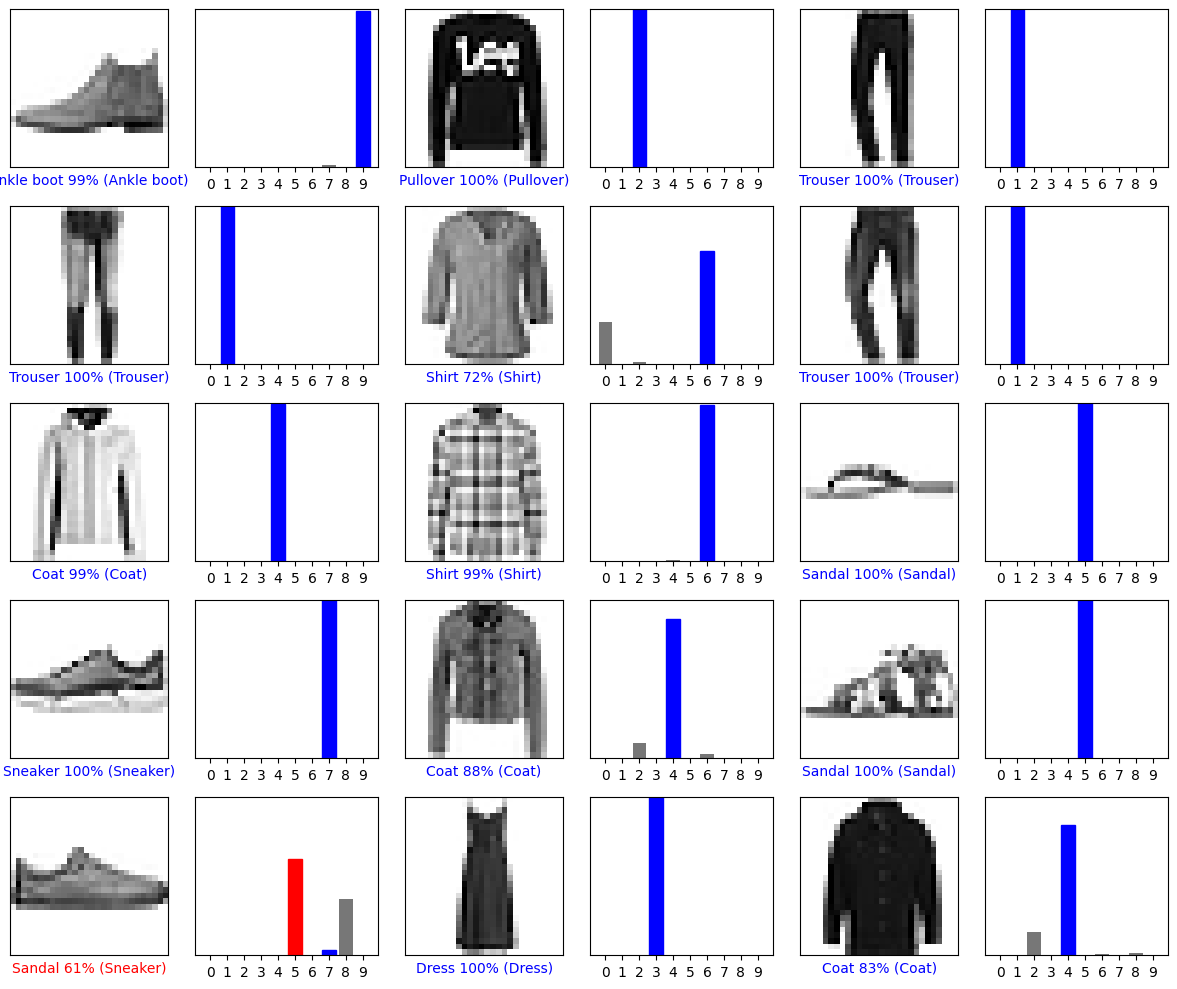

In [26]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

TEST Model

(28, 28)


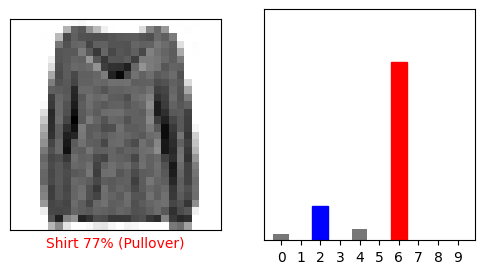

In [69]:
# Grab an image from the test dataset.
img = test_images[49]
print(img.shape)

i = 49
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

In [70]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


In [71]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[2.6888104e-02 7.7796622e-06 1.4793327e-01 1.7730087e-03 4.9005572e-02
  5.4499731e-07 7.7137089e-01 1.5805936e-07 3.0164539e-03 4.1298172e-06]]


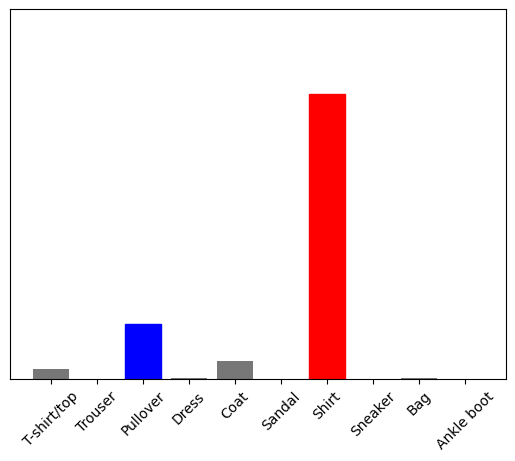

In [73]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

In [74]:
np.argmax(predictions_single[0])

6

In [75]:
print("Prédictions multiples (predictions[i]) :", predictions[i])
print("Prédictions pour une seule image (predictions_single[0]) :", predictions_single[0])


Prédictions multiples (predictions[i]) : [2.6888091e-02 7.7796631e-06 1.4793326e-01 1.7730129e-03 4.9005564e-02
 5.4499895e-07 7.7137095e-01 1.5805952e-07 3.0164598e-03 4.1298213e-06]
Prédictions pour une seule image (predictions_single[0]) : [2.6888104e-02 7.7796622e-06 1.4793327e-01 1.7730087e-03 4.9005572e-02
 5.4499731e-07 7.7137089e-01 1.5805936e-07 3.0164539e-03 4.1298172e-06]


In [77]:
# Afficher le label réel pour l'image 59
print(f"Label réel pour l'image 59 : {test_labels[49]}")
# Afficher la classe prédite
print(f"Classe prédite par le modèle : {np.argmax(predictions[i])}")


Label réel pour l'image 59 : 2
Classe prédite par le modèle : 6


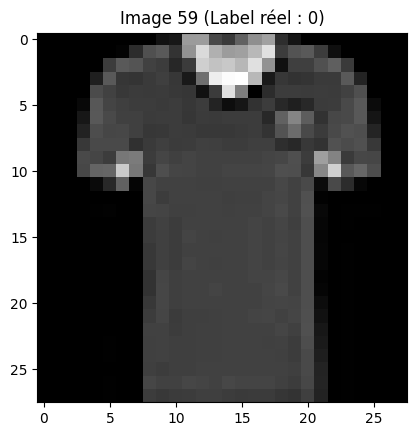

In [59]:
plt.imshow(test_images[59], cmap='gray')
plt.title(f"Image 59 (Label réel : {test_labels[59]})")
plt.show()